In [62]:
import qutip as qt
import numpy as np
import matplotlib.pyplot as plt




## Plot Function

In [63]:


def plot_spectrum(w_list, S3_topo, S3_triv, levels=60, figsize=(12, 14), save_path=None, xlim=None, ylim=None, auto_z_scale=False):
    """
    Displays a 3x2 figure with 2D spectra for the topological and trivial phases.
    - xlim, ylim : Tuples (min, max) pour zoomer sur les axes w1 et w3.
    - auto_z_scale : Si True, ajuste l'échelle de couleur (colorbar) en fonction 
                     uniquement des valeurs contenues dans la région zoomée.
    """
    fig, axes = plt.subplots(3, 2, figsize=figsize)

    # --- 1. Détermination de la région de données pour l'échelle de couleur ---
    if (xlim is not None or ylim is not None) and auto_z_scale:
        x_mask = (w_list >= xlim[0]) & (w_list <= xlim[1]) if xlim is not None else np.ones_like(w_list, dtype=bool)
        y_mask = (w_list >= ylim[0]) & (w_list <= ylim[1]) if ylim is not None else np.ones_like(w_list, dtype=bool)
        
        # Isoler les données visibles pour ajuster l'échelle Z
        S3_topo_zoom = S3_topo[np.ix_(y_mask, x_mask)]
        S3_triv_zoom = S3_triv[np.ix_(y_mask, x_mask)]
    else:
        S3_topo_zoom = S3_topo
        S3_triv_zoom = S3_triv

    # ==========================================
    # ROW 1: REAL PART
    # ==========================================
    lim_real_topo = np.max(np.abs(np.real(S3_topo_zoom)))
    lim_real_triv = np.max(np.abs(np.real(S3_triv_zoom)))
    
    c00 = axes[0, 0].contourf(w_list, w_list, np.real(S3_topo), levels, 
                              cmap='RdBu_r', vmin=-lim_real_topo, vmax=lim_real_topo)
    axes[0, 0].set_title(r"Real / Topo ($t_2 > t_1$)")
    axes[0, 0].set_ylabel(r"$\omega_3$")
    fig.colorbar(c00, ax=axes[0, 0])
    
    c01 = axes[0, 1].contourf(w_list, w_list, np.real(S3_triv), levels, 
                              cmap='RdBu_r', vmin=-lim_real_triv, vmax=lim_real_triv)
    axes[0, 1].set_title(r"Real / Triv ($t_1 > t_2$)")
    fig.colorbar(c01, ax=axes[0, 1])

    # ==========================================
    # ROW 2: IMAGINARY PART
    # ==========================================
    lim_imag_topo = np.max(np.abs(np.imag(S3_topo_zoom)))
    lim_imag_triv = np.max(np.abs(np.imag(S3_triv_zoom)))
    
    c10 = axes[1, 0].contourf(w_list, w_list, np.imag(S3_topo), levels, 
                              cmap='RdBu_r', vmin=-lim_imag_topo, vmax=lim_imag_topo)
    axes[1, 0].set_title(r"Imag / Topo ($t_2 > t_1$)")
    axes[1, 0].set_ylabel(r"$\omega_3$")
    fig.colorbar(c10, ax=axes[1, 0])
    
    c11 = axes[1, 1].contourf(w_list, w_list, np.imag(S3_triv), levels, 
                              cmap='RdBu_r', vmin=-lim_imag_triv, vmax=lim_imag_triv)
    axes[1, 1].set_title(r"Imag / Triv ($t_1 > t_2$)")
    fig.colorbar(c11, ax=axes[1, 1])

    # ==========================================
    # ROW 3: ABSOLUTE VALUE
    # ==========================================
    lim_abs_topo = np.max(np.abs(S3_topo_zoom))
    lim_abs_triv = np.max(np.abs(S3_triv_zoom))
    
    c20 = axes[2, 0].contourf(w_list, w_list, np.abs(S3_topo), levels, 
                              cmap='magma', vmin=0, vmax=lim_abs_topo)
    axes[2, 0].set_title(r"Abs / Topo ($t_2 > t_1$)")
    axes[2, 0].set_xlabel(r"$\omega_1$")
    axes[2, 0].set_ylabel(r"$\omega_3$")
    fig.colorbar(c20, ax=axes[2, 0])
    
    c21 = axes[2, 1].contourf(w_list, w_list, np.abs(S3_triv), levels, 
                              cmap='magma', vmin=0, vmax=lim_abs_triv)
    axes[2, 1].set_title(r"Abs / Triv ($t_1 > t_2$)")
    axes[2, 1].set_xlabel(r"$\omega_1$")
    fig.colorbar(c21, ax=axes[2, 1])

    # --- 2. Application du Zoom sur tous les graphiques ---
    for ax in axes.flat:
        if xlim is not None:
            ax.set_xlim(xlim)
        if ylim is not None:
            ax.set_ylim(ylim)

    plt.tight_layout()
    
    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Figure saved at: {save_path}")
        
    plt.show()

### Some operators definition for numpy calculus

In [64]:
'''Liouville super operator'''
def spre_numpy(A):
    # Correspond à (I \otimes A) pour la convention "flatten('F')"
    N = A.shape[0]
    res = np.zeros((N, 4, 4), dtype=complex)
    res[:, 0:2, 0:2] = A
    res[:, 2:4, 2:4] = A
    return res

def spost_numpy(B):
    # Correspond à (B^T \otimes I)
    N = B.shape[0]
    res = np.zeros((N, 4, 4), dtype=complex)
    res[:, 0, 0] = B[:, 0, 0]; res[:, 1, 1] = B[:, 0, 0]
    res[:, 0, 2] = B[:, 1, 0]; res[:, 1, 3] = B[:, 1, 0]
    res[:, 2, 0] = B[:, 0, 1]; res[:, 3, 1] = B[:, 0, 1]
    res[:, 2, 2] = B[:, 1, 1]; res[:, 3, 3] = B[:, 1, 1]
    return res

## Modele related function



In [65]:

'''
def get_H_and_Js_numpy(k_array, t1, t2):
    N = len(k_array)
    H_mat = np.zeros((N, 2, 2), dtype=complex)
    H_mat[:, 0, 1] = t1 + t2 * np.exp(-1j * k_array)
    H_mat[:, 1, 0] = t1 + t2 * np.exp(1j * k_array)
    
    J_k_mat = np.zeros((N, 2, 2), dtype=complex)
    J_k_mat[:, 0, 1] = -1j * t2 * np.exp(-1j * k_array)
    J_k_mat[:, 1, 0] = 1j * t2 * np.exp(1j * k_array)
    
    J_minusk_mat = np.zeros((N, 2, 2), dtype=complex)
    J_minusk_mat[:, 0, 1] = -1j * t2 * np.exp(1j * k_array)
    J_minusk_mat[:, 1, 0] = 1j * t2 * np.exp(-1j * k_array)
    
    return H_mat, J_k_mat, J_minusk_mat
'''

def get_H_and_Js_RWA_numpy(k_array, t1, t2):
    N = len(k_array)
    
    # 1. Hamiltonien dans la base des sites (A et B)
    H_site = np.zeros((N, 2, 2), dtype=complex)
    H_site[:, 0, 1] = t1 + t2 * np.exp(-1j * k_array)
    H_site[:, 1, 0] = t1 + t2 * np.exp(1j * k_array)
    
    # 2. Diagonalisation pour passer dans la base des ÉNERGIES (Bandes)
    # np.linalg.eigh trie les valeurs propres : 
    # Indice 0 = Bande de Valence (basse énergie)
    # Indice 1 = Bande de Conduction (haute énergie)
    evals, evecs = np.linalg.eigh(H_site)
    
    # L'Hamiltonien devient purement diagonal dans cette base
    H_eigen = np.zeros((N, 2, 2), dtype=complex)
    H_eigen[:, 0, 0] = evals[:, 0] 
    H_eigen[:, 1, 1] = evals[:, 1] 
    
    # 3. L'opérateur de courant dans la base des sites
    J_site = np.zeros((N, 2, 2), dtype=complex)
    J_site[:, 0, 1] = -1j * t2 * np.exp(-1j * k_array)
    J_site[:, 1, 0] =  1j * t2 * np.exp( 1j * k_array)
    
    # 4. Rotation de J dans la base des énergies : J_eigen = V^\dagger * J_site * V
    V = evecs
    V_dag = np.conj(V.transpose(0, 2, 1))
    J_eigen = V_dag @ J_site @ V
    
    # ==========================================================
    # 5. APPLICATION DE LA RWA : Séparation des excitations/émissions
    # ==========================================================
    
    J_plus = np.zeros((N, 2, 2), dtype=complex)
    # J+ (Excitation) : Fait passer de la Valence (0) à la Conduction (1)
    # C'est l'élément matriciel <1 | J | 0>
    J_plus[:, 1, 0] = J_eigen[:, 1, 0]
    
    J_minus = np.zeros((N, 2, 2), dtype=complex)
    # J- (Émission) : Fait passer de la Conduction (1) à la Valence (0)
    # C'est l'élément matriciel <0 | J | 1>
    J_minus[:, 0, 1] = J_eigen[:, 0, 1]
    
    return H_eigen, J_plus, J_minus


def get_thermal_state_numpy(H_mat, T, mu=0.0):
    # np.linalg.eigh fonctionne nativement sur un batch de matrices (N, 2, 2)
    evals, evecs = np.linalg.eigh(H_mat) 
    
    # Distribution de Fermi-Dirac (taille N, 2)
    f_occ = 1.0 / (np.exp((evals - mu) / T) + 1.0)
    
    rho_eq = np.zeros_like(H_mat)
    # Construction de rho_eq par produit externe pour chaque k
    for i in range(2):
        vec = evecs[:, :, i:i+1] # Vecteur propre i
        vec_dag = np.conj(vec.transpose(0, 2, 1))
        rho_eq += f_occ[:, i:i+1, np.newaxis] * (vec @ vec_dag)
        
    return rho_eq


def sigma_frohlich(omega, omega_LO, lam, eta, T):
    """Calculates the self-energy (complex scalar)."""
    n_ph = 1.0 / (np.exp(omega_LO / T) - 1.0)
    term1 = (n_ph + 1.0) / ((omega - omega_LO) + 1j * eta)
    term2 = n_ph / ((omega + omega_LO) + 1j * eta)
    return (lam**2) * (term1 + term2)


def get_L_eff_numpy(H_eigen, w, wLO, lam, eta, T, c_ops=None):
    # Si on utilise Lindblad, on n'a plus forcément besoin du Sigma non-hermitien
    # L_super = spre_numpy(H_eigen) - spost_numpy(H_eigen)
    
    # Pour garder la rétrocompatibilité avec ton code :
    Sigma = sigma_frohlich(w, wLO, lam, eta, T)
    H_eff = H_eigen + Sigma * np.eye(2)
    
    # Le Liouvillien cohérent de base: -i[H, rho]
    # (Note: Le -i est appliqué plus tard dans tes fonctions de Green)
    L_super = spre_numpy(H_eff) - spost_numpy(H_eff)
    
    # AJOUT DE LA DISSIPATION LINDBLAD
    if c_ops is not None:
        for C_mat, gamma in c_ops:
            # On ajoute la matrice de Lindblad (qui inclut le terme +i en Liouville)
            # Attention au facteur -i global dans ton code, il faut souvent diviser par -i
            # pour que la dissipation reste réelle lors de l'évolution temporelle.
            L_super += 1j * lindblad_dissipator_numpy(C_mat, gamma)
            
    return L_super

def get_green_functions_numpy(L_w1,L_0, L_w3, tau2, w1, w3, eta):
    I_4 = np.eye(4)
    
    # L'inversion matricielle est ultra-rapide et vectorisée
    G1_mat = np.linalg.inv((-w1 + 1j * eta) * I_4 - L_w1)
    G3_mat = np.linalg.inv((w3 + 1j * eta) * I_4 - L_w3)
    
    # Calcul vectorisé de expm(-1j * L * tau2) via diagonalisation
    evals, evecs = np.linalg.eig(-1j * L_0 * tau2) 
    evecs_inv = np.linalg.inv(evecs)
    exp_D = np.exp(evals) 
    G2_mat = (evecs * exp_D[:, np.newaxis, :]) @ evecs_inv
    
    return G1_mat, G2_mat, G3_mat

def calc_rephasing_S3_vectorized(k_array, w3, w1, tau2,params, c_ops=None):
    t1, t2 = params["t1"], params["t2"]
    eta, T = params["Eta"], params["T"]
    wLO, lam, mu = params["omegaLO"], params["lambda"], params["mu"]

    # 1. Génération des blocs dans la base des ÉNERGIES (RWA)
    # On récupère l'Hamiltonien diagonal et les opérateurs RWA purs
    H_eigen, J_plus, J_minus = get_H_and_Js_RWA_numpy(k_array, t1, t2)
    rho_eq = get_thermal_state_numpy(H_eigen, T, mu)

    # 2. Superopérateurs (Respectant la RWA)
    # J_plus ne fait QUE monter en énergie, J_minus ne fait QUE descendre
    JL_plus = spre_numpy(J_plus)
    JR_plus = spost_numpy(J_plus)
    JR_minus = spost_numpy(J_minus)
    
    # Opérateur de trace finale (mesure du dipôle / courant total)
    J_total = J_plus + J_minus
    JL_out = spre_numpy(J_total)

    # 3. Propagateurs (Utilisent H_eigen, la dynamique est désormais diagonale)
    L_w1 = get_L_eff_numpy(H_eigen, w1, wLO, lam, eta, T,c_ops)
    L_w3 = get_L_eff_numpy(H_eigen, w3, wLO, lam, eta, T, c_ops)
    L_0  = get_L_eff_numpy(H_eigen, 0.0, wLO, lam, eta, T, c_ops)
    G1, G2, G3 = get_green_functions_numpy(L_w1, L_0, L_w3, tau2, w1, w3, eta)

    # 4. Aplatissement de la matrice de densité (équivalent 'F' de numpy/QuTiP)
    N = len(k_array)
    rho_vec = np.zeros((N, 4, 1), dtype=complex)
    rho_vec[:, 0, 0] = rho_eq[:, 0, 0]
    rho_vec[:, 1, 0] = rho_eq[:, 1, 0]
    rho_vec[:, 2, 0] = rho_eq[:, 0, 1]
    rho_vec[:, 3, 0] = rho_eq[:, 1, 1]

    # ========================================================================
    # 5. Chemins de Feynman (Spectroscopie de Rephasage : -k1, +k2, +k3)
    # L'ordre d'application doit être rigoureux pour respecter la RWA.
    # ========================================================================
    
    # GSB : Absorbe -k1 sur le bra (JR_minus), interagit +k2 sur le bra (JR_plus), sonde +k3 sur le ket (JL_plus)
    path_GSB = G3 @ (JL_plus @ (G2 @ (JR_plus @ (G1 @ (JR_minus @ rho_vec)))))

    # SE : Absorbe -k1 sur le bra (JR_minus), interagit +k2 sur le ket (JL_plus), sonde +k3 sur le bra (JR_plus)
    path_SE  = G3 @ (JR_plus @ (G2 @ (JL_plus @ (G1 @ (JR_minus @ rho_vec)))))

    # ESA : Absorbe -k1 sur le bra (JR_minus), interagit +k2 sur le ket (JL_plus), interagit +k3 sur le ket (JL_plus)
    path_ESA = G3 @ (JL_plus @ (G2 @ (JL_plus @ (G1 @ (JR_minus @ rho_vec)))))

    # 6. Traces finales
    I_vec = np.zeros((N, 1, 4), dtype=complex)
    I_vec[:, 0, 0] = 1.0 
    I_vec[:, 0, 3] = 1.0

    tr_GSB = (I_vec @ (JL_out @ path_GSB)).reshape(-1)
    tr_SE  = (I_vec @ (JL_out @ path_SE)).reshape(-1)
    tr_ESA = (I_vec @ (JL_out @ path_ESA)).reshape(-1)

    # Addition des signaux (Soustraction conventionnelle de l'ESA)
    total_trace = -1j * (tr_GSB + tr_SE - tr_ESA)

    return total_trace

def calc_nonrephasing_S3_vectorized(k_array, w3, w1, tau2, params, c_ops=None):
    t1, t2 = params["t1"], params["t2"]
    eta, T = params["Eta"], params["T"]
    wLO, lam, mu = params["omegaLO"], params["lambda"], params["mu"]

    # 1. Génération des blocs dans la base des ÉNERGIES (RWA)
    H_eigen, J_plus, J_minus = get_H_and_Js_RWA_numpy(k_array, t1, t2)
    rho_eq = get_thermal_state_numpy(H_eigen, T, mu)

    # 2. Superopérateurs (Respectant la RWA)
    JL_plus  = spre_numpy(J_plus)
    JR_plus  = spost_numpy(J_plus)
    JL_minus = spre_numpy(J_minus)  # Requis pour le GSB en non-rephasage
    JR_minus = spost_numpy(J_minus)
    
    J_total = J_plus + J_minus
    JL_out  = spre_numpy(J_total)

    # 3. Liouvilliens de base
    L_w1 = get_L_eff_numpy(H_eigen, w1, wLO, lam, eta, T, c_ops)
    L_w3 = get_L_eff_numpy(H_eigen, w3, wLO, lam, eta, T, c_ops)
    L_0  = get_L_eff_numpy(H_eigen, 0.0, wLO, lam, eta, T, c_ops)
    
    # 3.5 Propagateurs G1, G2, G3 intégrés pour gérer le changement de signe de w1
    I_4 = np.eye(4)
    # ATTENTION : w1 est POSITIF ici pour le non-rephasage (+k1)
    G1 = np.linalg.inv((w1 + 1j * eta) * I_4 - L_w1)
    G3 = np.linalg.inv((w3 + 1j * eta) * I_4 - L_w3)
    
    evals, evecs = np.linalg.eig(-1j * L_0 * tau2) 
    evecs_inv = np.linalg.inv(evecs)
    exp_D = np.exp(evals) 
    G2 = (evecs * exp_D[:, np.newaxis, :]) @ evecs_inv

    # 4. Aplatissement de la matrice de densité (état thermique initial)
    N = len(k_array)
    rho_vec = np.zeros((N, 4, 1), dtype=complex)
    rho_vec[:, 0, 0] = rho_eq[:, 0, 0]
    rho_vec[:, 1, 0] = rho_eq[:, 1, 0]
    rho_vec[:, 2, 0] = rho_eq[:, 0, 1]
    rho_vec[:, 3, 0] = rho_eq[:, 1, 1]

    # ========================================================================
    # 5. Chemins de Feynman (Spectroscopie de NON-Rephasage : +k1, -k2, +k3)
    # ========================================================================
    
    # GSB : Absorbe +k1 sur le ket (JL_plus), émet -k2 sur le ket (JL_minus), absorbe +k3 sur le ket (JL_plus)
    path_GSB = G3 @ (JL_plus @ (G2 @ (JL_minus @ (G1 @ (JL_plus @ rho_vec)))))

    # SE : Absorbe +k1 sur le ket (JL_plus), émet -k2 sur le bra (JR_minus), absorbe +k3 sur le bra (JR_plus)
    path_SE  = G3 @ (JR_plus @ (G2 @ (JR_minus @ (G1 @ (JL_plus @ rho_vec)))))

    # ESA : Absorbe +k1 sur le ket (JL_plus), émet -k2 sur le bra (JR_minus), absorbe +k3 sur le ket (JL_plus)
    # (S'annulera naturellement car le système n'a que 2 bandes)
    path_ESA = G3 @ (JL_plus @ (G2 @ (JR_minus @ (G1 @ (JL_plus @ rho_vec)))))

    # 6. Traces finales
    I_vec = np.zeros((N, 1, 4), dtype=complex)
    I_vec[:, 0, 0] = 1.0 
    I_vec[:, 0, 3] = 1.0

    tr_GSB = (I_vec @ (JL_out @ path_GSB)).reshape(-1)
    tr_SE  = (I_vec @ (JL_out @ path_SE)).reshape(-1)
    tr_ESA = (I_vec @ (JL_out @ path_ESA)).reshape(-1)

    # Addition des signaux (Soustraction conventionnelle de l'ESA)
    total_trace = -1j * (tr_GSB + tr_SE - tr_ESA)

    return total_trace

def generate_rephasing_2D_spectrum_vectorized(w1_list, w3_list, tau2, params, n_kpoints,c_ops=None):
    k_array = np.linspace(-np.pi, np.pi, n_kpoints)
    dk = k_array[1] - k_array[0]
    
    S3_grid = np.zeros((len(w3_list), len(w1_list)), dtype=complex)
    
    # Boucle unique sur les fréquences
    for i, w3 in enumerate(w3_list):
        for j, w1 in enumerate(w1_list):
            
            # APPEL UNIQUE: Calcule instantanément la réponse pour les 100 000 k-points
            S3_vec = calc_rephasing_S3_vectorized(k_array, w3, w1, tau2, params,c_ops)
            
            # Intégration sur k
            S3_grid[i, j] = np.sum(S3_vec) * dk / (2 * np.pi)
            
    return S3_grid

def generate_nonrephasing_2D_spectrum_vectorized(w1_list, w3_list, tau2, params, n_kpoints,c_ops=None):
    k_array = np.linspace(-np.pi, np.pi, n_kpoints)
    dk = k_array[1] - k_array[0]
    
    S3_grid = np.zeros((len(w3_list), len(w1_list)), dtype=complex)
    
    # Boucle unique sur les fréquences
    for i, w3 in enumerate(w3_list):
        for j, w1 in enumerate(w1_list):
            
            # APPEL UNIQUE: Calcule instantanément la réponse pour les 100 000 k-points
            S3_vec = calc_nonrephasing_S3_vectorized(k_array, w3, w1, tau2, params, c_ops)
            
            # Intégration sur k
            S3_grid[i, j] = np.sum(S3_vec) * dk / (2 * np.pi)
            
    return S3_grid

def generate_absolue_2D_spectrum_vectorized(w1_list, w3_list, tau2, params, n_kpoints, c_ops=None):
    k_array = np.linspace(-np.pi, np.pi, n_kpoints)
    dk = k_array[1] - k_array[0]
    
    S3_grid_rephasing = np.zeros((len(w3_list), len(w1_list)), dtype=complex)
    S3_grid_nonrephasing = np.zeros((len(w3_list), len(w1_list)), dtype=complex)
    
    # Boucle unique sur les fréquences
    for i, w3 in enumerate(w3_list):
        for j, w1 in enumerate(w1_list):
            
            # APPEL UNIQUE: Calcule instantanément la réponse pour les 100 000 k-points
            S3_vec_rephasing = calc_rephasing_S3_vectorized(k_array, w3, w1, tau2, params, c_ops)
            S3_vec_nonrephasing = calc_nonrephasing_S3_vectorized(k_array, w3, w1, tau2, params, c_ops)
            
            # Intégration sur k
            S3_grid_rephasing[i, j] = np.sum(S3_vec_rephasing) * dk / (2 * np.pi)
            S3_grid_nonrephasing[i, j] = np.sum(S3_vec_nonrephasing) * dk / (2 * np.pi)
            
    return S3_grid_rephasing, S3_grid_nonrephasing

def lindblad_dissipator_numpy(C_mat, gamma):
    """
    Génère la matrice de superopérateur de Lindblad 4x4 pour un opérateur de saut C_mat.
    C_mat doit être un tableau numpy de dimension (N, 2, 2)
    """
    # 1. Opérateur conjugué hermitien (C^\dagger)
    # On transpose les axes 1 et 2 (les dimensions 2x2) et on prend le complexe conjugué
    C_dag = np.conj(C_mat.transpose(0, 2, 1))
    
    # 2. Produit C^\dagger * C (@ est la multiplication matricielle vectorisée)
    C_dag_C = C_dag @ C_mat
    
    # 3. Construction des termes de Lindblad via nos superopérateurs
    # Terme 1: C * rho * C^\dagger  ->  spre(C) @ spost(C^\dagger)
    term1 = spre_numpy(C_mat) @ spost_numpy(C_dag)
    
    # Terme 2: -1/2 * C^\dagger * C * rho  ->  spre(C^\dagger * C)
    term2 = -0.5 * spre_numpy(C_dag_C)
    
    # Terme 3: -1/2 * rho * C^\dagger * C  ->  spost(C^\dagger * C)
    term3 = -0.5 * spost_numpy(C_dag_C)
    
    # On retourne la somme pondérée par le taux gamma
    return gamma * (term1 + term2 + term3)


In [66]:
'''
TOTAL_KPOINTS = 100
w_list = np.linspace(0.5, 1.5, 100) 
tau2_test = 0.0  # Updated according to your file
    
params_topo = {"t1": 1.0, "t2": 1.5, "Eta": 0.05, "T": 0.01, "mu": 0.0, "omegaLO": 1.0, "lambda": 0.1}
params_triv = {"t1": 1.0, "t2": 0.5, "Eta": 0.05, "T": 0.01, "mu": 0.0, "omegaLO": 1.0, "lambda": 0.1}
print(f"Calcul avec {TOTAL_KPOINTS} points (100% Vectorisé NumPy)...")

S3_topo = generate_2D_spectrum_vectorized(
    w_list, w_list, tau2_test, params_topo, n_kpoints=TOTAL_KPOINTS
)

S3_triv = generate_2D_spectrum_vectorized(
    w_list, w_list, tau2_test, params_triv, n_kpoints=TOTAL_KPOINTS
)

plot_spectrum(w_list, S3_topo, S3_triv)

'''




'\nTOTAL_KPOINTS = 100\nw_list = np.linspace(0.5, 1.5, 100) \ntau2_test = 0.0  # Updated according to your file\n\nparams_topo = {"t1": 1.0, "t2": 1.5, "Eta": 0.05, "T": 0.01, "mu": 0.0, "omegaLO": 1.0, "lambda": 0.1}\nparams_triv = {"t1": 1.0, "t2": 0.5, "Eta": 0.05, "T": 0.01, "mu": 0.0, "omegaLO": 1.0, "lambda": 0.1}\nprint(f"Calcul avec {TOTAL_KPOINTS} points (100% Vectorisé NumPy)...")\n\nS3_topo = generate_2D_spectrum_vectorized(\n    w_list, w_list, tau2_test, params_topo, n_kpoints=TOTAL_KPOINTS\n)\n\nS3_triv = generate_2D_spectrum_vectorized(\n    w_list, w_list, tau2_test, params_triv, n_kpoints=TOTAL_KPOINTS\n)\n\nplot_spectrum(w_list, S3_topo, S3_triv)\n\n'

Calcul avec 100 points (100% Vectorisé NumPy)...


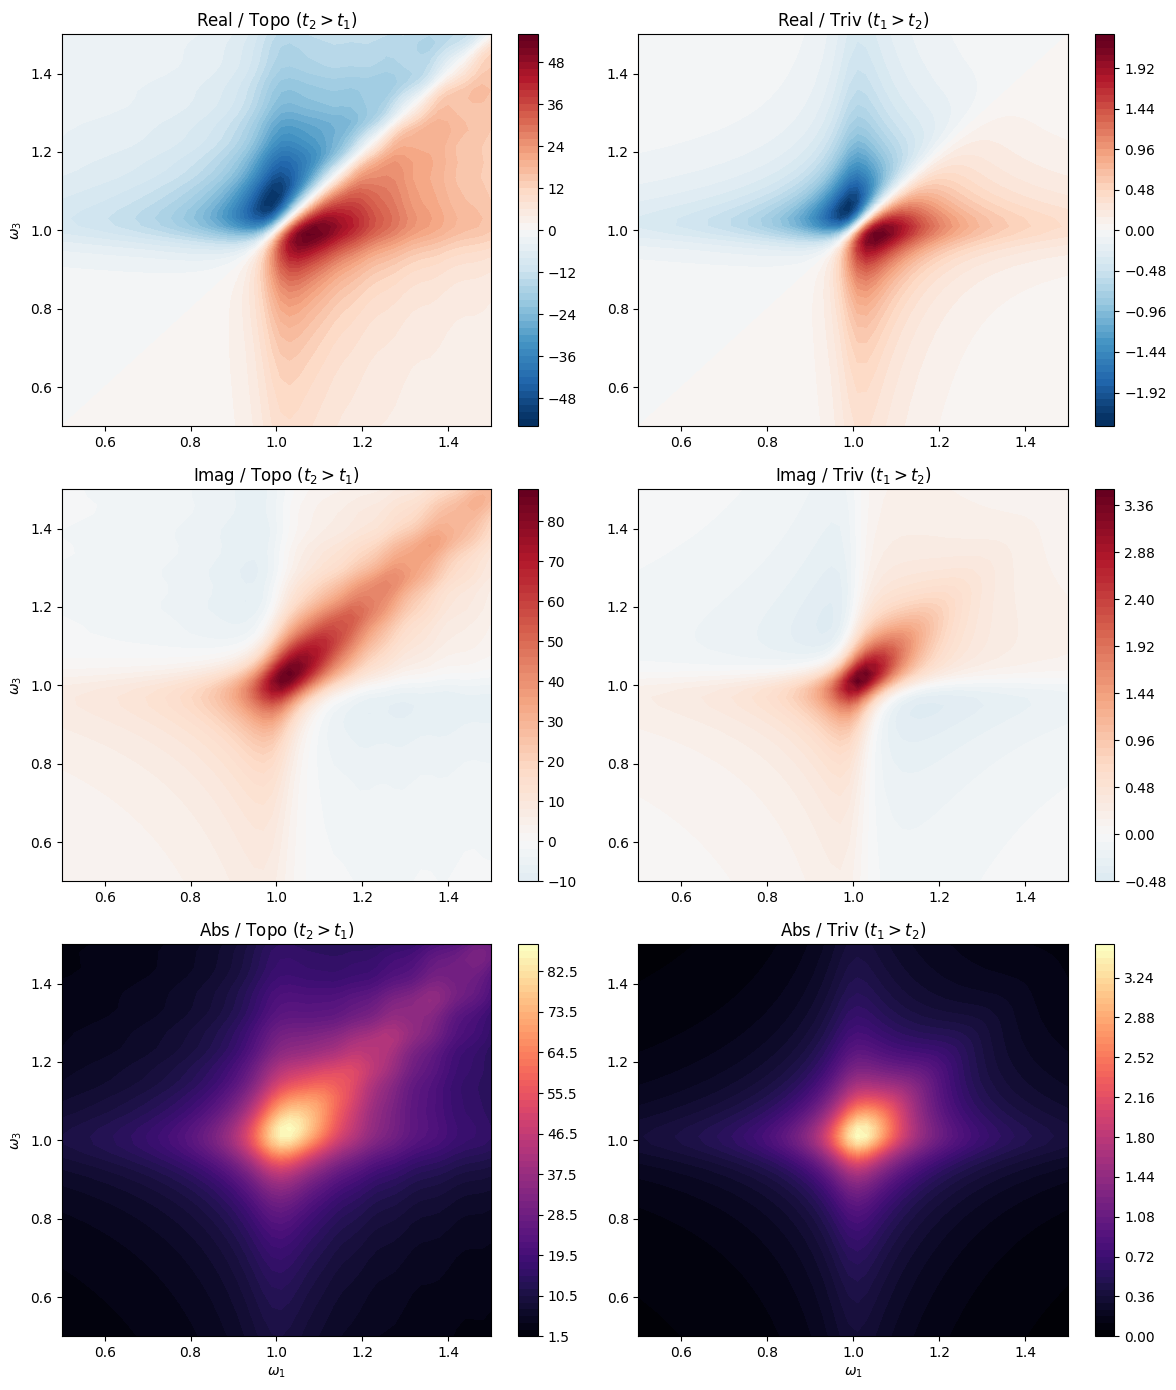

'\nS3_rephasing_topo, S3_unrephasing_topo =generate_absolue_2D_spectrum_vectorized( w_list, w_list, tau2_test, params_topo, n_kpoints=TOTAL_KPOINTS,c_ops=c_ops_topo)\n\nS3_rephasing_triv,S3_unrephasing_triv = generate_absolue_2D_spectrum_vectorized( w_list, w_list, tau2_test, params_triv,n_kpoints=TOTAL_KPOINTS, c_ops= c_ops_triv)\n\nS3_total_topo = (S3_rephasing_topo + S3_unrephasing_topo)\nS3_total_triv = (S3_rephasing_triv + S3_unrephasing_triv)\n\n\nprint("Rephasing spectra")\nplot_spectrum(w_list, S3_rephasing_topo, S3_rephasing_triv)\nprint("unrephasing spectra")\nplot_spectrum(w_list, S3_unrephasing_topo, S3_unrephasing_triv)\nprint("absolue spectra ")\nplot_spectrum(w_list,S3_total_topo,S3_total_triv)\n'

In [73]:
TOTAL_KPOINTS = 100
w_list = np.linspace(0.5, 1.5, 50) 
tau2_test = 30  # Updated according to your file


params_topo = {"t1": 1.0, "t2": 1.5, "Eta": 0.05, "T": 0.01, "mu": 0.0, "omegaLO": 1.0, "lambda": 0.1}
params_triv = {"t1": 1.0, "t2": 0.5, "Eta": 0.05, "T": 0.01, "mu": 0.0, "omegaLO": 1.0, "lambda": 0.1}
print(f"Calcul avec {TOTAL_KPOINTS} points (100% Vectorisé NumPy)...")


k_array = np.linspace(-np.pi, np.pi, TOTAL_KPOINTS)

t1_topo, t2_topo = params_topo["t1"], params_topo["t2"]
t1_triv, t2_triv = params_triv["t1"], params_triv["t2"]

H,J_plus_topo,J_minus_topo=get_H_and_Js_RWA_numpy(k_array,t1_topo,t2_topo )
H,J_plus_triv,J_minus_triv=get_H_and_Js_RWA_numpy(k_array,t1_triv,t2_triv )

gamma_1= 0.01
c_ops_topo = [(J_minus_topo, gamma_1)]
c_ops_triv = [(J_minus_triv, gamma_1)]
S3_rephasing_topo=generate_rephasing_2D_spectrum_vectorized( w_list, w_list, tau2_test, params_topo, n_kpoints=TOTAL_KPOINTS,c_ops=c_ops_topo)
S3_rephasing_triv=generate_rephasing_2D_spectrum_vectorized( w_list, w_list, tau2_test, params_triv, n_kpoints=TOTAL_KPOINTS, c_ops=c_ops_triv)
plot_spectrum(w_list, S3_rephasing_topo, S3_rephasing_triv)

'''
S3_rephasing_topo, S3_unrephasing_topo =generate_absolue_2D_spectrum_vectorized( w_list, w_list, tau2_test, params_topo, n_kpoints=TOTAL_KPOINTS,c_ops=c_ops_topo)

S3_rephasing_triv,S3_unrephasing_triv = generate_absolue_2D_spectrum_vectorized( w_list, w_list, tau2_test, params_triv,n_kpoints=TOTAL_KPOINTS, c_ops= c_ops_triv)

S3_total_topo = (S3_rephasing_topo + S3_unrephasing_topo)
S3_total_triv = (S3_rephasing_triv + S3_unrephasing_triv)


print("Rephasing spectra")
plot_spectrum(w_list, S3_rephasing_topo, S3_rephasing_triv)
print("unrephasing spectra")
plot_spectrum(w_list, S3_unrephasing_topo, S3_unrephasing_triv)
print("absolue spectra ")
plot_spectrum(w_list,S3_total_topo,S3_total_triv)
'''


Calcul avec 100 points (100% Vectorisé NumPy)...


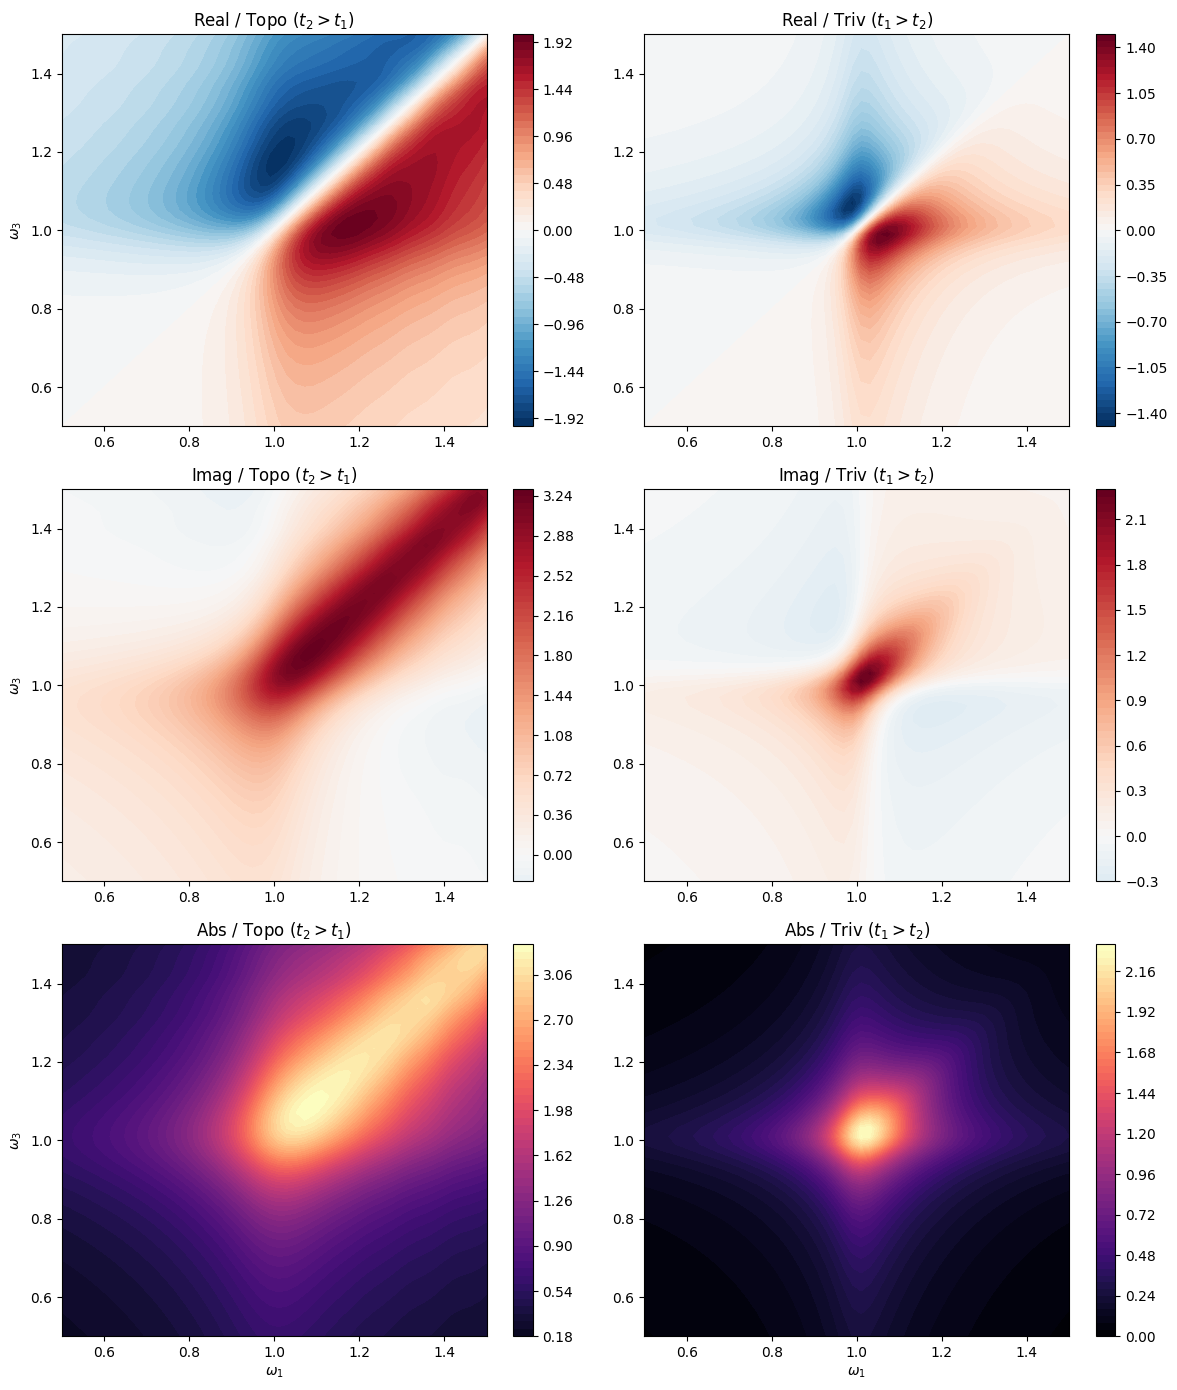

In [75]:
TOTAL_KPOINTS = 100
w_list = np.linspace(0.5, 1.5, 50) 
tau2_test = 30  # Updated according to your file


params_topo = {"t1": 1.0, "t2": 1.5, "Eta": 0.05, "T": 0.01, "mu": 0.0, "omegaLO": 1.0, "lambda": 0.1}
params_triv = {"t1": 1.0, "t2": 0.5, "Eta": 0.05, "T": 0.01, "mu": 0.0, "omegaLO": 1.0, "lambda": 0.1}
print(f"Calcul avec {TOTAL_KPOINTS} points (100% Vectorisé NumPy)...")


k_array = np.linspace(-np.pi, np.pi, TOTAL_KPOINTS)

t1_topo, t2_topo = params_topo["t1"], params_topo["t2"]
t1_triv, t2_triv = params_triv["t1"], params_triv["t2"]

H,J_plus_topo,J_minus_topo=get_H_and_Js_RWA_numpy(k_array,t1_topo,t2_topo )
H,J_plus_triv,J_minus_triv=get_H_and_Js_RWA_numpy(k_array,t1_triv,t2_triv )

gamma_1= 0.05
c_ops_topo = [(J_minus_topo, gamma_1)]
c_ops_triv = [(J_minus_triv, gamma_1)]
S3_rephasing_topo=generate_rephasing_2D_spectrum_vectorized( w_list, w_list, tau2_test, params_topo, n_kpoints=TOTAL_KPOINTS,c_ops=c_ops_topo)
S3_rephasing_triv=generate_rephasing_2D_spectrum_vectorized( w_list, w_list, tau2_test, params_triv, n_kpoints=TOTAL_KPOINTS, c_ops=c_ops_triv)
plot_spectrum(w_list, S3_rephasing_topo, S3_rephasing_triv)